# Chapter 3: Financial Fraud Detection

Every payment processor faces the same tension: flag too little and fraudulent transactions go through; flag too much and legitimate customers get blocked. Rules-based systems -- velocity checks, amount thresholds, country blocklists -- are fast but brittle. They miss novel fraud patterns and block legitimate transactions that happen to look unusual.

This chapter uses Jev to make a single binary decision for each incoming transaction: flag it for review, or pass it through? One call, two options, a calibrated confidence score. The confidence score is what makes this useful in production: a transaction flagged with 0.99 confidence goes straight to the fraud queue, while one flagged with 0.61 confidence might warrant a softer intervention -- a one-time password, a confirmation SMS -- rather than an outright block.

## Prerequisites

```shell
export TYPESAFE_API_KEY="your-typesafe-key"
```

## 1. Install dependencies

In [1]:
%pip install pandas==2.2.3 \
             plotly==6.1.2 \
             typesafe-sdk==0.7.2 --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Imports and configuration

In [2]:
import os
import pandas as pd
import plotly.graph_objects as go
import time

from typesafe_sdk import Choice, TypeSafeClient

In [3]:
TYPESAFE_API_KEY = os.environ["TYPESAFE_API_KEY"]

print("Configuration set.")

Configuration set.


## 3. Decision options

A single binary `Choice` per transaction.

In [4]:
FRAUD_DECISION = {
    "Flag": (
        "Transaction shows one or more indicators of potential fraud. "
        "Hold for manual review or trigger step-up authentication."
    ),
    "Pass": (
        "Transaction appears consistent with the account's normal behaviour. "
        "Approve and process."
    ),
}

print("Options:", list(FRAUD_DECISION.keys()))

Options: ['Flag', 'Pass']


## 4. Generate synthetic transactions

Twenty transactions across four bands:

- **Clear fraud**: multiple stacked risk signals
- **Clear legitimate**: established account, normal behaviour
- **Ambiguous**: one or two flags but not conclusive
- **Edge cases**: unusual but legitimate patterns

Each transaction carries the contextual signals a real fraud system would have access to: amount, merchant category, location, time of day, account history and transaction velocity.

In [5]:
TRANSACTIONS = [

    # Clear fraud (5)
    {
        "id": "TX001",
        "amount_usd": 4200,
        "merchant_category": "Electronics",
        "merchant_name": "TechGadgets Direct",
        "location": "International -- Lagos, Nigeria",
        "time_of_day": "03:14 local time",
        "account_age_days": 3,
        "previous_flags": 0,
        "transactions_last_hour": 7,
        "typical_monthly_spend_usd": 800,
        "note": "New account, high velocity, large amount, international, late night",
        "band": "clear_fraud",
    },
    {
        "id": "TX002",
        "amount_usd": 9800,
        "merchant_category": "Wire Transfer",
        "merchant_name": "GlobalPay Wire Services",
        "location": "International -- multiple countries in 2 hours",
        "time_of_day": "02:30 local time",
        "account_age_days": 12,
        "previous_flags": 1,
        "transactions_last_hour": 4,
        "typical_monthly_spend_usd": 1200,
        "note": "Previously flagged, wire transfer, impossible travel, late night",
        "band": "clear_fraud",
    },
    {
        "id": "TX003",
        "amount_usd": 650,
        "merchant_category": "ATM Withdrawal",
        "merchant_name": "ATM -- Bucharest Central",
        "location": "International -- Bucharest, Romania",
        "time_of_day": "23:50 local time",
        "account_age_days": 8,
        "previous_flags": 2,
        "transactions_last_hour": 3,
        "typical_monthly_spend_usd": 500,
        "note": "Multiple prior flags, international ATM, late night, new account",
        "band": "clear_fraud",
    },
    {
        "id": "TX004",
        "amount_usd": 1500,
        "merchant_category": "Gift Cards",
        "merchant_name": "QuickStop Mart",
        "location": "Domestic -- different city from home",
        "time_of_day": "11:20 local time",
        "account_age_days": 5,
        "previous_flags": 0,
        "transactions_last_hour": 5,
        "typical_monthly_spend_usd": 600,
        "note": "Gift cards are high-fraud category, new account, high velocity",
        "band": "clear_fraud",
    },
    {
        "id": "TX005",
        "amount_usd": 3100,
        "merchant_category": "Electronics",
        "merchant_name": "DigitalMart Online",
        "location": "International -- Kiev, Ukraine",
        "time_of_day": "01:05 local time",
        "account_age_days": 2,
        "previous_flags": 0,
        "transactions_last_hour": 9,
        "typical_monthly_spend_usd": 400,
        "note": "Brand new account, extreme velocity, large amount, international",
        "band": "clear_fraud",
    },

    # Clear legitimate (5)
    {
        "id": "TX006",
        "amount_usd": 87,
        "merchant_category": "Grocery",
        "merchant_name": "FreshMart Superstore",
        "location": "Home city -- usual neighbourhood",
        "time_of_day": "17:45 local time",
        "account_age_days": 1840,
        "previous_flags": 0,
        "transactions_last_hour": 1,
        "typical_monthly_spend_usd": 2200,
        "note": "Established account, routine grocery shop, home location",
        "band": "clear_legit",
    },
    {
        "id": "TX007",
        "amount_usd": 42,
        "merchant_category": "Restaurant",
        "merchant_name": "Corner Bistro",
        "location": "Home city",
        "time_of_day": "12:30 local time",
        "account_age_days": 2650,
        "previous_flags": 0,
        "transactions_last_hour": 1,
        "typical_monthly_spend_usd": 3100,
        "note": "Long-established account, small lunch purchase, home city",
        "band": "clear_legit",
    },
    {
        "id": "TX008",
        "amount_usd": 320,
        "merchant_category": "Travel",
        "merchant_name": "SkyBridge Airlines",
        "location": "Home city -- online purchase",
        "time_of_day": "10:15 local time",
        "account_age_days": 990,
        "previous_flags": 0,
        "transactions_last_hour": 1,
        "typical_monthly_spend_usd": 2800,
        "note": "Established account, known airline, normal amount, business hours",
        "band": "clear_legit",
    },
    {
        "id": "TX009",
        "amount_usd": 55,
        "merchant_category": "Gas Station",
        "merchant_name": "FastFuel Station",
        "location": "Home city -- 2 miles from home",
        "time_of_day": "08:10 local time",
        "account_age_days": 3200,
        "previous_flags": 0,
        "transactions_last_hour": 1,
        "typical_monthly_spend_usd": 1900,
        "note": "Very established account, routine fuel purchase, morning commute",
        "band": "clear_legit",
    },
    {
        "id": "TX010",
        "amount_usd": 1200,
        "merchant_category": "Home Improvement",
        "merchant_name": "BuildRight Hardware",
        "location": "Home city",
        "time_of_day": "14:00 local time",
        "account_age_days": 1560,
        "previous_flags": 0,
        "transactions_last_hour": 1,
        "typical_monthly_spend_usd": 2500,
        "note": "Established account, known retailer, slightly above typical but plausible",
        "band": "clear_legit",
    },

    # Ambiguous (5)
    {
        "id": "TX011",
        "amount_usd": 2800,
        "merchant_category": "Electronics",
        "merchant_name": "TechZone Store",
        "location": "Home city",
        "time_of_day": "16:30 local time",
        "account_age_days": 720,
        "previous_flags": 0,
        "transactions_last_hour": 1,
        "typical_monthly_spend_usd": 1800,
        "note": "Known merchant, home city, but amount is 1.5x typical monthly spend",
        "band": "ambiguous",
    },
    {
        "id": "TX012",
        "amount_usd": 180,
        "merchant_category": "Restaurant",
        "merchant_name": "Café de la Place -- Paris, France",
        "location": "International -- Paris, France",
        "time_of_day": "20:15 local time",
        "account_age_days": 1100,
        "previous_flags": 0,
        "transactions_last_hour": 1,
        "typical_monthly_spend_usd": 2400,
        "note": "International but established account, normal amount, dinner time",
        "band": "ambiguous",
    },
    {
        "id": "TX013",
        "amount_usd": 95,
        "merchant_category": "Online Retail",
        "merchant_name": "ShopAll Online",
        "location": "Home city -- online",
        "time_of_day": "02:10 local time",
        "account_age_days": 880,
        "previous_flags": 0,
        "transactions_last_hour": 1,
        "typical_monthly_spend_usd": 1600,
        "note": "Known merchant, normal amount, but 2am purchase",
        "band": "ambiguous",
    },
    {
        "id": "TX014",
        "amount_usd": 450,
        "merchant_category": "ATM Withdrawal",
        "merchant_name": "ATM -- Las Vegas, NV",
        "location": "Domestic -- Las Vegas, different from home city",
        "time_of_day": "23:30 local time",
        "account_age_days": 1300,
        "previous_flags": 0,
        "transactions_last_hour": 2,
        "typical_monthly_spend_usd": 2100,
        "note": "Established account, domestic ATM, but Vegas late night cash withdrawal",
        "band": "ambiguous",
    },
    {
        "id": "TX015",
        "amount_usd": 600,
        "merchant_category": "Jewelry",
        "merchant_name": "Lumière Jewellers",
        "location": "Home city",
        "time_of_day": "13:45 local time",
        "account_age_days": 430,
        "previous_flags": 0,
        "transactions_last_hour": 1,
        "typical_monthly_spend_usd": 900,
        "note": "Unusual category for this account, amount is above typical, but business hours",
        "band": "ambiguous",
    },

    # Edge cases (5)
    {
        "id": "TX016",
        "amount_usd": 5500,
        "merchant_category": "Electronics",
        "merchant_name": "MegaElectronics",
        "location": "Home city",
        "time_of_day": "11:00 local time",
        "account_age_days": 2100,
        "previous_flags": 0,
        "transactions_last_hour": 1,
        "typical_monthly_spend_usd": 1500,
        "note": "Very established account, known merchant, but amount is 3.5x typical monthly spend",
        "band": "edge",
    },
    {
        "id": "TX017",
        "amount_usd": 230,
        "merchant_category": "Online Gaming",
        "merchant_name": "GameVault Platform",
        "location": "Home city -- online",
        "time_of_day": "03:30 local time",
        "account_age_days": 650,
        "previous_flags": 0,
        "transactions_last_hour": 3,
        "typical_monthly_spend_usd": 800,
        "note": "Late night gaming purchase is normal for this category, but 3am and velocity",
        "band": "edge",
    },
    {
        "id": "TX018",
        "amount_usd": 8900,
        "merchant_category": "Travel",
        "merchant_name": "GlobalAir International",
        "location": "Home city -- online",
        "time_of_day": "09:30 local time",
        "account_age_days": 1750,
        "previous_flags": 0,
        "transactions_last_hour": 1,
        "typical_monthly_spend_usd": 3200,
        "note": "Very large amount but established account, known airline, business hours",
        "band": "edge",
    },
    {
        "id": "TX019",
        "amount_usd": 75,
        "merchant_category": "Pharmacy",
        "merchant_name": "MediCare Pharmacy",
        "location": "Home city",
        "time_of_day": "04:20 local time",
        "account_age_days": 980,
        "previous_flags": 0,
        "transactions_last_hour": 1,
        "typical_monthly_spend_usd": 1400,
        "note": "Small amount, known merchant, but 4am pharmacy visit is unusual",
        "band": "edge",
    },
    {
        "id": "TX020",
        "amount_usd": 12000,
        "merchant_category": "Jewelry",
        "merchant_name": "Maison Dorée",
        "location": "International -- Geneva, Switzerland",
        "time_of_day": "14:30 local time",
        "account_age_days": 3800,
        "previous_flags": 0,
        "transactions_last_hour": 1,
        "typical_monthly_spend_usd": 8500,
        "note": "Very large amount, international, but very established account with high typical spend",
        "band": "edge",
    },
]

transactions_df = pd.DataFrame(TRANSACTIONS)
print(f"Generated {len(transactions_df)} transactions")
print()
print(transactions_df[["id", "amount_usd", "merchant_category", "location", "band"]]
      .to_string(index=False))

Generated 20 transactions

   id  amount_usd merchant_category                                        location        band
TX001        4200       Electronics                 International -- Lagos, Nigeria clear_fraud
TX002        9800     Wire Transfer  International -- multiple countries in 2 hours clear_fraud
TX003         650    ATM Withdrawal             International -- Bucharest, Romania clear_fraud
TX004        1500        Gift Cards            Domestic -- different city from home clear_fraud
TX005        3100       Electronics                  International -- Kiev, Ukraine clear_fraud
TX006          87           Grocery                Home city -- usual neighbourhood clear_legit
TX007          42        Restaurant                                       Home city clear_legit
TX008         320            Travel                    Home city -- online purchase clear_legit
TX009          55       Gas Station                  Home city -- 2 miles from home clear_legit
TX010        

## 5. Jev fraud detection

One `Choice` call per transaction. The full transaction context goes into the state so Jev can weigh all signals together rather than applying rules sequentially.

In [6]:
jev_client = TypeSafeClient(model="jev-1.13.0")
print("Jev client ready.")

Jev client ready.


In [7]:
def assess_transaction(client, tx):
    state = {
        "amount_usd":                tx["amount_usd"],
        "merchant_category":         tx["merchant_category"],
        "merchant_name":             tx["merchant_name"],
        "location":                  tx["location"],
        "time_of_day":               tx["time_of_day"],
        "account_age_days":          tx["account_age_days"],
        "previous_flags":            tx["previous_flags"],
        "transactions_last_hour":    tx["transactions_last_hour"],
        "typical_monthly_spend_usd": tx["typical_monthly_spend_usd"],
    }

    t0 = time.time()
    response = client.system_one(
        state=state,
        questions={
            "decision": Choice(
                instructions=(
                    "Based on all available signals, should this transaction "
                    "be flagged for review or passed through? Consider the "
                    "amount relative to typical spend, account age, location, "
                    "time of day, velocity and any prior flags."
                ),
                criteria=FRAUD_DECISION,
            )
        },
    )
    elapsed = (time.time() - t0) * 1000
    answer  = response.choices["decision"]

    return {
        "id":          tx["id"],
        "amount_usd":  tx["amount_usd"],
        "category":    tx["merchant_category"],
        "band":        tx["band"],
        "decision":    answer.choice,
        "confidence":  round(answer.confidence, 2),
        "elapsed_ms":  round(elapsed, 1),
        "note":        tx["note"],
    }

In [8]:
results = []
for tx in TRANSACTIONS:
    result = assess_transaction(jev_client, tx)
    results.append(result)
    flag = "FLAG" if result["decision"] == "Flag" else "pass"
    print(f"{result['id']} [{result['band']:12}] "
          f"${result['amount_usd']:>6,} {result['category']:<20} "
          f"-> {flag} ({result['confidence']:.2f})")

results_df = pd.DataFrame(results)

TX001 [clear_fraud ] $ 4,200 Electronics          -> FLAG (1.00)
TX002 [clear_fraud ] $ 9,800 Wire Transfer        -> FLAG (1.00)
TX003 [clear_fraud ] $   650 ATM Withdrawal       -> FLAG (1.00)
TX004 [clear_fraud ] $ 1,500 Gift Cards           -> FLAG (1.00)
TX005 [clear_fraud ] $ 3,100 Electronics          -> FLAG (1.00)
TX006 [clear_legit ] $    87 Grocery              -> pass (1.00)
TX007 [clear_legit ] $    42 Restaurant           -> pass (1.00)
TX008 [clear_legit ] $   320 Travel               -> pass (0.99)
TX009 [clear_legit ] $    55 Gas Station          -> pass (1.00)
TX010 [clear_legit ] $ 1,200 Home Improvement     -> pass (0.99)
TX011 [ambiguous   ] $ 2,800 Electronics          -> pass (0.18)
TX012 [ambiguous   ] $   180 Restaurant           -> pass (0.97)
TX013 [ambiguous   ] $    95 Online Retail        -> pass (0.33)
TX014 [ambiguous   ] $   450 ATM Withdrawal       -> pass (0.22)
TX015 [ambiguous   ] $   600 Jewelry              -> pass (0.98)
TX016 [edge        ] $ 5,

## 6. Results

In [9]:
results_df[["id", "amount_usd", "category", "band", "decision", "confidence"]]

,id,amount_usd,category,band,decision,confidence
0,TX001,4200,Electronics,clear_fraud,Flag,1.00
1,TX002,9800,Wire Transfer,clear_fraud,Flag,1.00
2,TX003,650,ATM Withdrawal,clear_fraud,Flag,1.00
3,TX004,1500,Gift Cards,clear_fraud,Flag,1.00
4,TX005,3100,Electronics,clear_fraud,Flag,1.00
5,TX006,87,Grocery,clear_legit,Pass,1.00
6,TX007,42,Restaurant,clear_legit,Pass,1.00
7,TX008,320,Travel,clear_legit,Pass,0.99
8,TX009,55,Gas Station,clear_legit,Pass,1.00
9,TX010,1200,Home Improvement,clear_legit,Pass,0.99


## 7. Confidence by band

Clear fraud and clear legitimate transactions should produce the highest confidence. Ambiguous and edge cases should produce lower confidence where the signals are genuinely mixed.

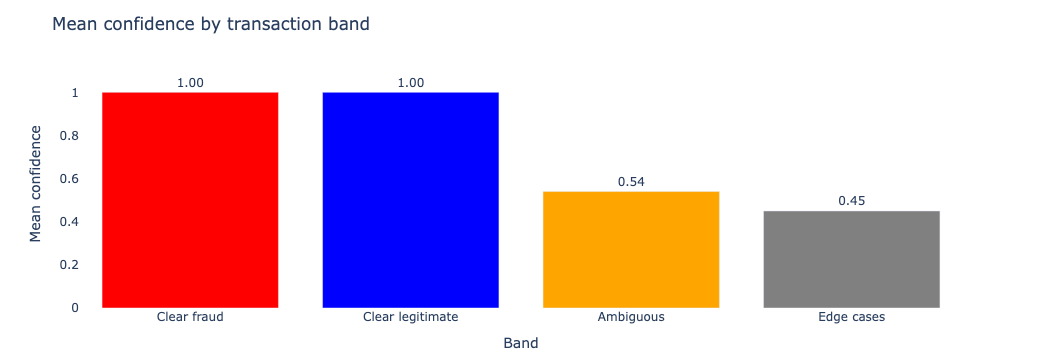


      band_label  mean_confidence  count  flagged
     Clear fraud             1.00      5        5
Clear legitimate             1.00      5        0
       Ambiguous             0.54      5        0
      Edge cases             0.45      5        2


In [10]:
band_order  = ["clear_fraud", "clear_legit", "ambiguous", "edge"]
band_labels = {
    "clear_fraud": "Clear fraud",
    "clear_legit": "Clear legitimate",
    "ambiguous":   "Ambiguous",
    "edge":        "Edge cases",
}

band_summary = (
    results_df
    .groupby("band")
    .agg(
        mean_confidence =("confidence", "mean"),
        count           =("id",         "count"),
        flagged         =("decision",   lambda x: (x == "Flag").sum()),
    )
    .reset_index()
)
band_summary["band"] = pd.Categorical(
    band_summary["band"], categories=band_order, ordered=True
)
band_summary = band_summary.sort_values("band")
band_summary["band_label"] = band_summary["band"].map(band_labels)
band_summary["mean_confidence"] = band_summary["mean_confidence"].round(2)

fig1 = go.Figure(go.Bar(
    x=band_summary["band_label"],
    y=band_summary["mean_confidence"],
    marker_color=["red", "blue", "orange", "grey"],
    text=[f"{v:.2f}" for v in band_summary["mean_confidence"]],
    textposition="outside",
))
fig1.update_layout(
    title="Mean confidence by transaction band",
    xaxis_title="Band",
    yaxis_title="Mean confidence",
    yaxis=dict(range=[0, 1.15]),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, b=40),
)
fig1.show()

print()
print(band_summary[["band_label", "mean_confidence", "count", "flagged"]]
      .to_string(index=False))

## 8. Confidence by merchant category

Some merchant categories carry inherently more uncertainty than others. Gift cards, wire transfers and ATM withdrawals are high-risk categories where even low amounts warrant scrutiny. Airlines and groceries are low-risk where context matters more than category.

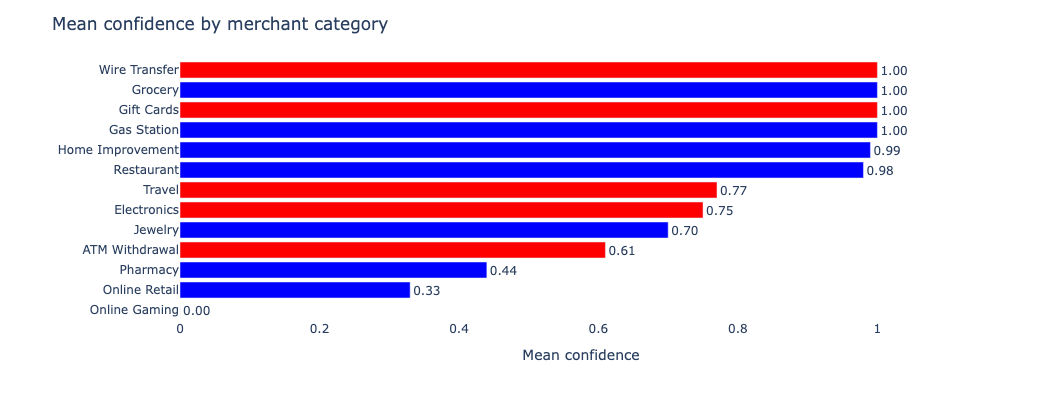


        category  mean_confidence  count  flagged  flag_rate
   Online Gaming             0.00      1        0       0.00
   Online Retail             0.33      1        0       0.00
        Pharmacy             0.44      1        0       0.00
  ATM Withdrawal             0.61      2        1       0.50
         Jewelry             0.70      2        0       0.00
     Electronics             0.75      4        3       0.75
          Travel             0.77      2        1       0.50
      Restaurant             0.98      2        0       0.00
Home Improvement             0.99      1        0       0.00
     Gas Station             1.00      1        0       0.00
      Gift Cards             1.00      1        1       1.00
         Grocery             1.00      1        0       0.00
   Wire Transfer             1.00      1        1       1.00


In [11]:
cat_summary = (
    results_df
    .groupby("category")
    .agg(
        mean_confidence=("confidence", "mean"),
        count          =("id",         "count"),
        flagged        =("decision",   lambda x: (x == "Flag").sum()),
    )
    .reset_index()
    .sort_values("mean_confidence")
)
cat_summary["mean_confidence"] = cat_summary["mean_confidence"].round(2)
cat_summary["flag_rate"] = (cat_summary["flagged"] / cat_summary["count"]).round(2)

fig2 = go.Figure(go.Bar(
    x=cat_summary["mean_confidence"],
    y=cat_summary["category"],
    orientation="h",
    marker_color=["red" if f > 0 else "blue"
                  for f in cat_summary["flagged"]],
    text=[f"{v:.2f}" for v in cat_summary["mean_confidence"]],
    textposition="outside",
))
fig2.update_layout(
    title="Mean confidence by merchant category",
    xaxis_title="Mean confidence",
    xaxis=dict(range=[0, 1.15]),
    yaxis_title="",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, l=180, r=60),
    height=400,
)
fig2.show()

print()
print(cat_summary[["category", "mean_confidence", "count", "flagged", "flag_rate"]]
      .to_string(index=False))

## 9. Low-confidence transactions

Transactions where confidence falls below 0.70 are candidates for step-up authentication (a one-time password or confirmation SMS) rather than an outright flag or a silent pass.

In [12]:
CONFIDENCE_THRESHOLD = 0.70

low_conf = results_df[results_df["confidence"] < CONFIDENCE_THRESHOLD].copy()

if low_conf.empty:
    print(f"No transactions fell below the {CONFIDENCE_THRESHOLD} threshold.")
else:
    print(f"{len(low_conf)} transaction(s) below the {CONFIDENCE_THRESHOLD} "
          f"confidence threshold:\n")
    for _, row in low_conf.iterrows():
        print(f"  {row['id']} [{row['band']}]")
        print(f"    ${row['amount_usd']:,} -- {row['category']}")
        print(f"    Decision: {row['decision']} (confidence: {row['confidence']:.2f})")
        print(f"    Note: {row['note']}")
        print()

7 transaction(s) below the 0.7 confidence threshold:

  TX011 [ambiguous]
    $2,800 -- Electronics
    Decision: Pass (confidence: 0.18)
    Note: Known merchant, home city, but amount is 1.5x typical monthly spend

  TX013 [ambiguous]
    $95 -- Online Retail
    Decision: Pass (confidence: 0.33)
    Note: Known merchant, normal amount, but 2am purchase

  TX014 [ambiguous]
    $450 -- ATM Withdrawal
    Decision: Pass (confidence: 0.22)
    Note: Established account, domestic ATM, but Vegas late night cash withdrawal

  TX017 [edge]
    $230 -- Online Gaming
    Decision: Pass (confidence: 0.00)
    Note: Late night gaming purchase is normal for this category, but 3am and velocity

  TX018 [edge]
    $8,900 -- Travel
    Decision: Flag (confidence: 0.55)
    Note: Very large amount but established account, known airline, business hours

  TX019 [edge]
    $75 -- Pharmacy
    Decision: Pass (confidence: 0.44)
    Note: Small amount, known merchant, but 4am pharmacy visit is unusual



## 10. Flag vs pass summary

Flagged: 7 transactions
  Mean confidence: 0.91
  Bands: {'clear_fraud': 5, 'edge': 2}

Passed:  13 transactions
  Mean confidence: 0.66
  Bands: {'clear_legit': 5, 'ambiguous': 5, 'edge': 3}


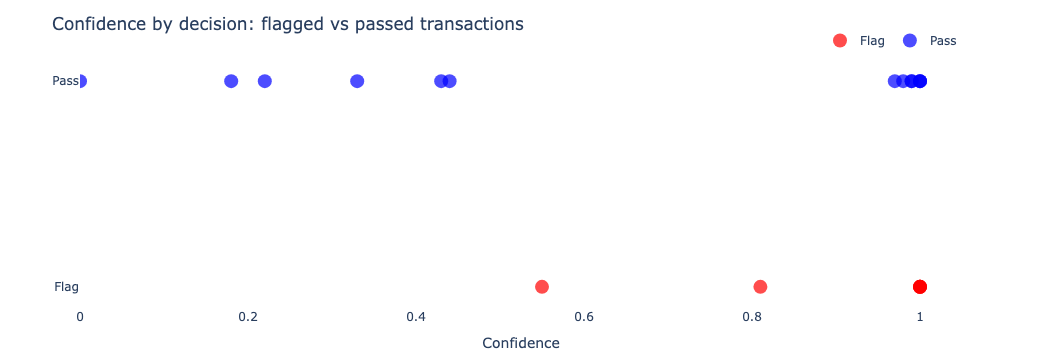

In [13]:
flagged = results_df[results_df["decision"] == "Flag"]
passed  = results_df[results_df["decision"] == "Pass"]

print(f"Flagged: {len(flagged)} transactions")
print(f"  Mean confidence: {flagged['confidence'].mean():.2f}")
print(f"  Bands: {flagged['band'].value_counts().to_dict()}")
print()
print(f"Passed:  {len(passed)} transactions")
print(f"  Mean confidence: {passed['confidence'].mean():.2f}")
print(f"  Bands: {passed['band'].value_counts().to_dict()}")

fig3 = go.Figure()

for decision, color in [("Flag", "red"), ("Pass", "blue")]:
    subset = results_df[results_df["decision"] == decision]
    fig3.add_trace(go.Scatter(
        x=subset["confidence"],
        y=subset["decision"],
        mode="markers",
        name=decision,
        marker=dict(color=color, size=14, opacity=0.7),
        text=subset["id"] + "<br>" + subset["category"] + "<br>$" +
             subset["amount_usd"].astype(str),
        hoverinfo="text+x",
    ))

fig3.update_layout(
    title="Confidence by decision: flagged vs passed transactions",
    xaxis_title="Confidence",
    xaxis=dict(range=[0, 1.05]),
    yaxis_title="",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, b=40),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig3.show()

## 11. Latency

In [14]:
print(f"Mean: {results_df['elapsed_ms'].mean():.0f}ms")
print(f"Min:  {results_df['elapsed_ms'].min():.0f}ms")
print(f"Max:  {results_df['elapsed_ms'].max():.0f}ms")

Mean: 242ms
Min:  192ms
Max:  470ms


## 12. Summary

One `Choice` call per transaction assessed 20 payments and returned a decision and a calibrated confidence score for each one. Clear fraud and clear legitimate transactions produced high confidence. Ambiguous and edge cases produced lower confidence, which is the correct signal -- those are the transactions where a simple rules-based decision would be most likely to get it wrong.

The confidence score enables a three-tier response rather than a binary flag-or-pass decision: high-confidence flags go straight to the fraud queue, high-confidence passes go straight through, and low-confidence decisions trigger step-up authentication. This is more nuanced than any fixed-threshold rules system and requires no rule maintenance as fraud patterns evolve.